In [34]:
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np

In [35]:
insurance_data = pd.read_csv('insurance.csv')

<Axes: xlabel='bmi', ylabel='charges'>

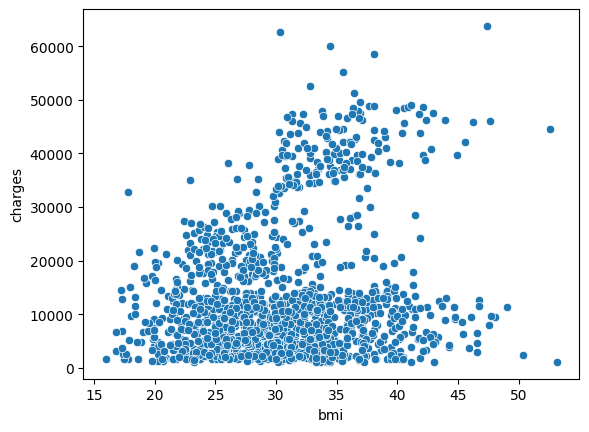

In [36]:
sns.scatterplot(data=insurance_data, x='bmi', y='charges')

<Axes: xlabel='bmi', ylabel='charges'>

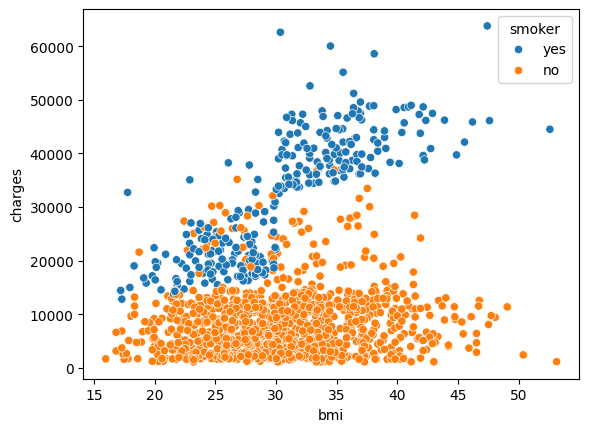

In [37]:
sns.scatterplot(data=insurance_data, x='bmi', y='charges', hue = insurance_data['smoker'])

In [38]:
X = insurance_data.drop(columns = ['charges','region'])
y = insurance_data['charges']

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

In [39]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [40]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [41]:
X_train.head()

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_test)

In [44]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [45]:
X_pred = model.predict(X_test)

In [46]:
X_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [47]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [48]:
#Evaluate

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print('r-square: ',r2)

r-square:  0.7811302113434095


In [49]:
n = X_test.shape[0]
p = X_test.shape[1]

In [50]:
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)

print('Adjusted r-square:',adjusted_r2)

Adjusted r-square: 0.7769533069797342


In [51]:
X_test.shape

(268, 5)

In [52]:
#One Hot Encoding

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

In [53]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,1
1,18,0,33.770,1,0,0,1,0
2,28,0,33.000,3,0,0,1,0
3,33,0,22.705,0,0,1,0,0
4,32,0,28.880,0,0,1,0,0


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 score: ',r2)

r2 score:  0.7835929767120724


In [55]:
#Interaction data

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

In [56]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 score: ',r2)

r2 score:  0.865231697953168


In [58]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

In [59]:
insurance_data = pd.read_csv('insurance.csv')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X = insurance_data.drop(columns = ['charges'])
y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)

X['sex'] = X['sex'].map({'male':0, 'female':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

MSE for alpha 0:  20922607.938070834
MSE for alpha 3e-05:  20922607.69598065
MSE for alpha 1:  20914832.635089148
MSE for alpha 5:  20890881.000633504
MSE for alpha 8:  20878416.54387192


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.281e+10, tolerance: 1.544e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

MSE for alpha 34:  20976742.86621093
MSE for alpha 6:  20886178.838931832
MSE for alpha 95:  22271646.280738153
MSE for alpha 44:  21100806.134182032
MSE for alpha 77:  21788313.586439915


<Axes: >

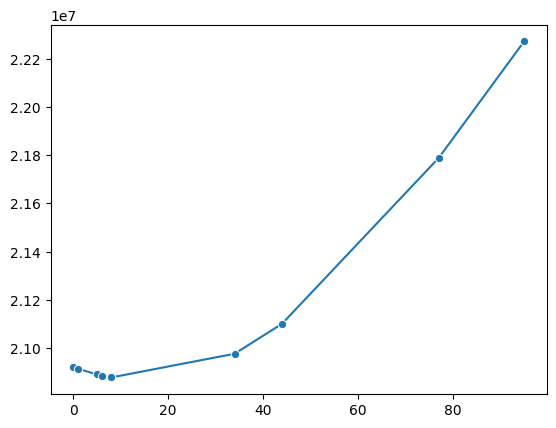

In [60]:
alpha = [0, 0.00003, 1, 5, 8, 34, 6, 95, 44, 77]
mses = []

for a in alpha:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha {a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alpha, y=mses, marker="o")

In [61]:
from sklearn.linear_model import LassoCV
alphas = [0, 0.00003, 1, 5, 8, 34, 6, 95, 44, 77]

lasso_cv_model = LassoCV(
    alphas=alphas,
    cv=10,
    max_iter=100000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("Best Alpha: ", lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse= ", mse)
print("s2: ", r2)


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.169e+10, tolerance: 1.395e+07
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast

Best Alpha:  0.0
mse=  20922607.938070834
s2:  0.8652316979531681


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.281e+10, tolerance: 1.544e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
a=[0.01,0.1,2,5,20,30,50,100]
rcv=RidgeCV(
    alphas=a,
    cv=5
)
rcv.fit(X_train,y_train)
y_pred=rcv.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))
print("best alpha",rcv.alpha_)

MAE : 2757.7619456549814
MSE : 20920713.85887192
RMSE: 4573.916686918545
R2  : 0.8652438982409303
best alpha 0.01


In [63]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=5)
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


MAE : 2872.28613421605
MSE : 23580839.093831766
RMSE: 4856.010615086397
R2  : 0.848109296177526


In [64]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=200,max_depth=4,max_leaf_nodes=25)
rfr.fit(X_train,y_train)
y_pred=rfr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 2682.6167593909386
MSE : 20265001.994467285
RMSE: 4501.666579664389
R2  : 0.8694675196393401


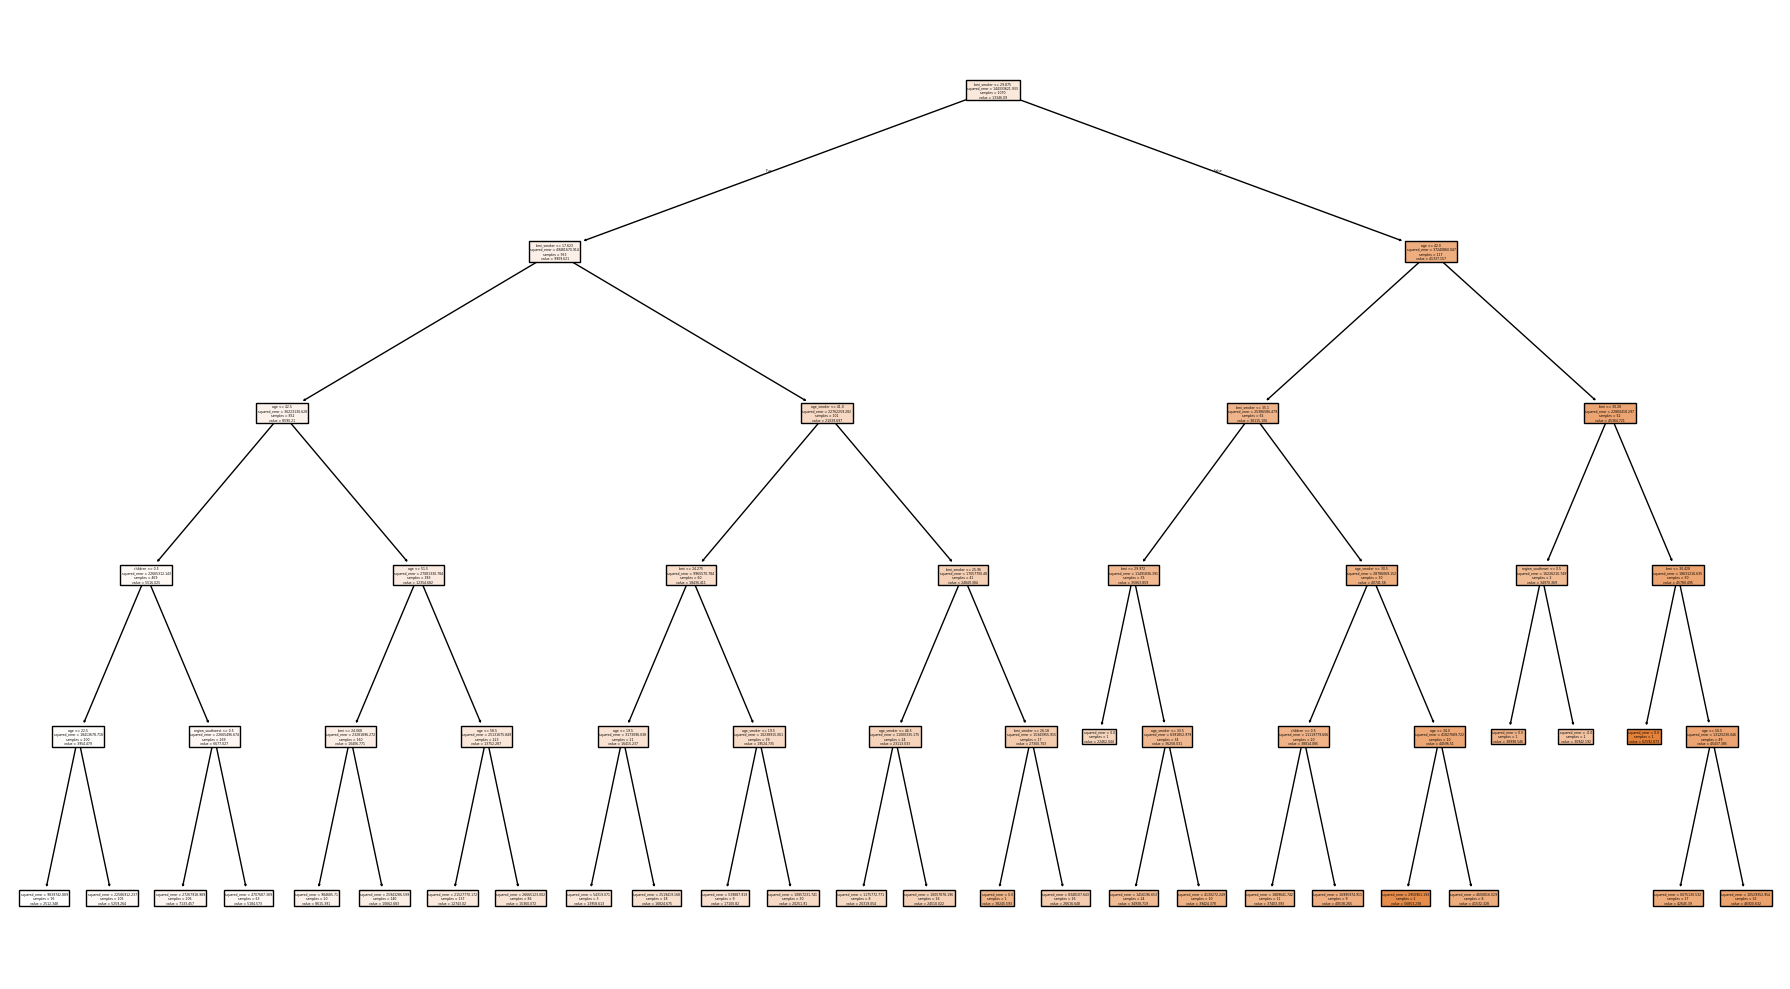

In [65]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [66]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, subsample=0.8)

gbr.fit(X_train,y_train)
y_pred=gbr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 2496.089784210195
MSE : 19609295.97076624
RMSE: 4428.238472662266
R2  : 0.8736911034161634


In [67]:
import xgboost as xgb
model1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 2436.990690364739
MSE : 18355545.974381845
RMSE: 4284.337285319848
R2  : 0.8817668537578067


## 🏆 Best Model

After comparing all the regression models, **XGBoost Regressor** achieved the best performance.

- **Best Model:** XGBoost Regressor
- **R² Score:** **88.17%**

An R² score of **88.17%** indicates that the XGBoost model explains approximately **88.17% of the variation in annual medical costs**, making it the best-performing model among the algorithms evaluated.